In [2]:
import os
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
current_dir_path = Path.cwd()
files = os.listdir(current_dir_path)
# print(files)

for file in files:
    if file == 'all_percolations.csv':
        all_percolations = pd.read_csv(file, index_col = 0)
        # all_percolations.columns = ['Time (min)', 'Area (sq ' + u"\u03bcm" + ')', 'Percolation Direction']
        display(all_percolations)

,Time (min),Area (%),Percolation Direction
0,5.0,36.179060,left to right
1,5.2,42.227981,left to right
2,5.3,45.343976,left to right
3,5.3,45.343976,top to bottom
4,5.4,48.488054,left to right
...,...,...,...
995,6.7,82.027409,top to bottom
996,6.7,82.027409,top to bottom
997,6.7,82.027409,left to right
998,6.8,83.633411,top to bottom


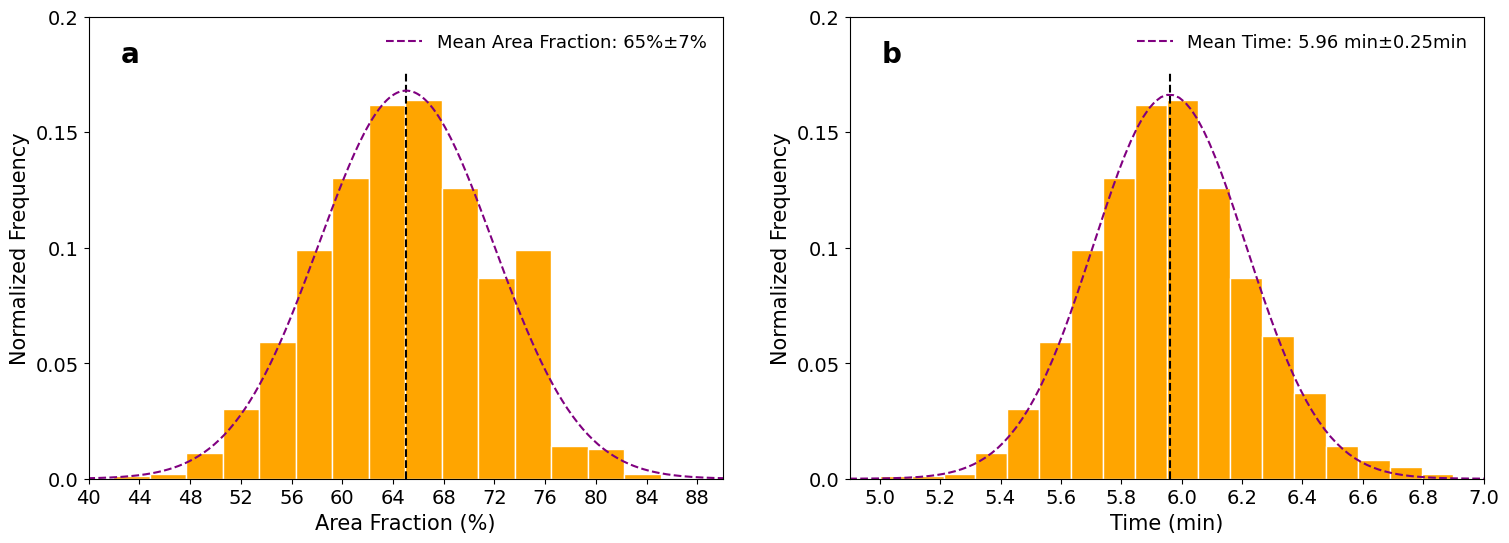

In [4]:
from scipy.stats import norm
import numpy as np

# Number of plots = 2
fig, ax = plt.subplots(1, 2, figsize = (18, 6))


## First plot (Surface Coverage Area)
percentages = all_percolations['Area (%)']
percentages = [float(percentage) for percentage in percentages]


mean_percentage, std_percentage = norm.fit(percentages)
xmin_percentage, xmax_percentage = 0, 100
x_percentage = np.linspace(xmin_percentage, xmax_percentage, 500)
p_percentage = norm.pdf(x_percentage, mean_percentage, std_percentage)
p_percentage *= 34 * np.max(percentages)
ax[0].axvline(mean_percentage, ymin = 0, ymax = 0.88, color = 'black', linestyle = '--') #, label = f'Mean Area Fraction {mean_percentage:.0f}%')
bins_percentage = np.arange(0, 105, 4)
ax[0].hist(percentages, bins = 17, edgecolor = 'white', color = 'orange')
ax[0].plot(x_percentage, p_percentage, linestyle = '--', label = f'Mean Area Fraction: {mean_percentage:.0f}%' + u"\u00b1" + f'{std_percentage:.0f}%', c = 'purple')
ax[0].set_xlabel('Area Fraction (%)', fontsize = 15)
ax[0].set_ylabel('Normalized Frequency', fontsize = 15)
ax[0].set_xticks(bins_percentage)
ax[0].set_xticklabels(labels = bins_percentage, fontsize = 14)
# ax[0].set_yticks(np.arange(0, 225, 25))
# ax[0].set_yticklabels(np.arange(0, 1.125, 0.125))
ax[0].set_yticks(np.arange(0, 1000, 50))
ax[0].set_yticklabels(np.round(np.arange(0, 1, 0.05), 4), fontsize = 14)
ax[0].set_xlim(40, 90)
ax[0].set_ylim(0, 200)
ax[0].legend(frameon = False, fontsize = 13, loc = 'upper right')
ax[0].text(0.05, 0.95, 'a', transform = ax[0].transAxes, fontsize = 20, fontweight = 'bold', va = 'top')



## Second plot (Time)
times = all_percolations['Time (min)']
times = [float(time) for time in times]


mean_time, std_time = norm.fit(times)
xmin_time, xmax_time = 0, 10
x_time = np.linspace(xmin_time, xmax_time, 500)
p_time = norm.pdf(x_time, mean_time, std_time)
p_time *= 15.3 * np.max(times)
ax[1].axvline(mean_time, ymin = 0, ymax = 0.88, color = 'black', linestyle = '--') #, label = f'Mean Time: {mean_time:.2f} min')
bins_time = np.arange(0, 10, 0.2)
ax[1].hist(times, bins = 18, edgecolor = 'white', color = 'orange')
ax[1].plot(x_time, p_time, linestyle = '--', label = f'Mean Time: {mean_time:.2f} min' + u"\u00b1" + f'{std_time:.2f}min', c = 'purple')
ax[1].set_xlabel('Time (min)', fontsize = 15)
ax[1].set_ylabel('Normalized Frequency', fontsize = 15)
ax[1].set_xticks(bins_time)
ax[1].set_xticklabels(labels = np.round(bins_time, 2), fontsize = 14)
# ax[1].set_yticks(np.arange(0, 225, 25))
# ax[1].set_yticklabels(np.arange(0, 1.125, 0.125))
ax[1].set_yticks(np.arange(0, 1000, 50))
ax[1].set_yticklabels(np.round(np.arange(0, 1, 0.05), 4), fontsize = 14)
ax[1].set_xlim(4.9, 7.0)
ax[1].set_ylim(0, 200)
ax[1].legend(frameon = False, fontsize = 13, loc = 'upper right')
ax[1].text(0.05, 0.95, 'b', transform = ax[1].transAxes, fontsize = 20, fontweight = 'bold', va = 'top')


plt.savefig('gaussian_curves.png')
plt.show()